**Description:**

The best-performing SAM model (LoRA rank 32) was evaluated on test set positions 117 and 211–217 from experiment EXP-23-BZ3167. The data folders used in this analysis have been uploaded to Google Drive.

Test Set Performance:

Dice: 0.8919
IoU: 0.8049

The trained model was then used to generate segmentation masks for subsequent figure creation.

The best model is available [here](https://drive.google.com/file/d/1kiCAM84ae75DxRlGof7iYZryYXro0HmH/view?usp=sharing)

In [1]:
!pip install -q torch torchvision
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python scikit-image pandas numpy matplotlib tqdm scikit-learn
!pip install -q loralib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
import os
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
import pickle
from pathlib import Path
from PIL import Image
import json
from tqdm import tqdm
from scipy.ndimage import label as ndimage_label
from skimage.morphology import remove_small_holes, remove_small_objects
import matplotlib.patches as patches
from collections import defaultdict
import random
import shutil
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.nn as nn
from segment_anything import sam_model_registry
import loralib as lora
from skimage.transform import resize as skimage_resize

# Helper functions

## Dataset Class

This dataset class loads raw images and their corresponding segmentation masks for both reference and treatment conditions.

It automatically pairs each image with the correct mask based on position folders, converts images to a consistent RGB format, and loads masks as integer-labeled instance maps. Optional augmentations can be applied through Albumentations. **The class returns image–mask pairs in a format compatible with PyTorch DataLoaders.**

In [5]:
class BacteriaSegmentationDataset(Dataset):
    def __init__(self,
                 ref_raw_dir, ref_mask_dir,
                 rif_raw_dir, rif_mask_dir,
                 positions,
                 transform=None):

        # Directories for raw images and masks (REF and RIF10 conditions)
        self.ref_raw_dir = ref_raw_dir
        self.ref_mask_dir = ref_mask_dir
        self.rif_raw_dir = rif_raw_dir
        self.rif_mask_dir = rif_mask_dir

        # Albumentations transforms (optional)
        self.transform = transform

        self.samples = [] # List of (image_path, mask_path) pairs
        self._collect_all_paths(positions)

        print(f"Loaded {len(self.samples)} samples")

    # Collect all raw–mask pairs from the given list of positions
    def _collect_all_paths(self, positions):
        for pos in positions:
            if pos < 200:
                # Positions <200 → reference data
                self.samples += self._collect_pos(self.ref_raw_dir, self.ref_mask_dir, pos)
            else:
                # Positions ≥200 → treatment data
                self.samples += self._collect_pos(self.rif_raw_dir, self.rif_mask_dir, pos)

    # Collect all files for a single position
    def _collect_pos(self, raw_dir, mask_dir, pos):
        samples = []
        pos_folder = f"Pos{pos}"

        raw_path = os.path.join(raw_dir, pos_folder, "aphase")
        mask_path = os.path.join(mask_dir, pos_folder, "PreprocessedPhaseMasks")

        if not os.path.exists(raw_path) or not os.path.exists(mask_path):
            print(f"[WARNING] Missing: {raw_path} or {mask_path}")
            return samples
        # Load all raw TIFF images and all corresponding mask files
        raw_files  = sorted([f for f in os.listdir(raw_path) if f.endswith(".tiff")])
        mask_files = sorted([f for f in os.listdir(mask_path) if f.startswith("MASK_")])

        # Pairing
        for rf, mf in zip(raw_files, mask_files):
            samples.append((
                os.path.join(raw_path, rf),
                os.path.join(mask_path, mf)
            ))

        return samples

    def _load_image(self, path):
        img = np.array(Image.open(path))

        # Convert grayscale → RGB
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)

        # Convert (H, W, 1) → RGB
        if img.ndim == 3 and img.shape[2] == 1:
            img = np.repeat(img, 3, axis=2)

        # Convert channel-first → channel-last (rare but safe check)
        if img.ndim == 3 and img.shape[0] == 3 and img.shape[2] != 3:
            img = np.transpose(img, (1, 2, 0))

        # Normalize intensity to 0–255 and convert to uint8
        if img.dtype != np.uint8:
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        return img


    def _load_mask(self, path):
        """Load instance mask"""
        mask = np.array(Image.open(path))

        # Ensure 2D mask (drop channel if present)
        if mask.ndim == 3:
            mask = mask[:, :, 0]

        return mask.astype(np.int32)  # Instance IDs as integers

    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        raw_path, mask_path = self.samples[idx]

        image = self._load_image(raw_path)
        mask = self._load_mask(mask_path)

        # Ensure mask size matches image size
        if mask.shape != image.shape[:2]:
            mask = cv2.resize(mask.astype(np.uint8),
                              (image.shape[1], image.shape[0]),
                              interpolation=cv2.INTER_NEAREST)

        # Apply augmentation
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        return {
            'image': image,
            'mask': mask,
            'image_path': raw_path,
            'mask_path': mask_path
        }



## Load Test Data

The test set consisted of reference positions 111–117 and treated positions 211–217, which were excluded from training and validation and used exclusively to assess model generalization.

In [6]:
test_positions = list(range(111, 118)) + list(range(211, 218))


ref_raw  = "dataset/REF_raw_data111_131_for_testing"
ref_mask = "dataset/REF_masks111_131_for_testing"

rif_raw  = "dataset/RIF10_raw_data211_217_for_testing"
rif_mask = "dataset/RIF10_masks211_217_for_testing"


test_dataset = BacteriaSegmentationDataset(
    ref_raw, ref_mask, rif_raw, rif_mask, test_positions
)

print("Test samples:", len(test_dataset))

Loaded 1694 samples
Test samples: 1694


## SAMFinetuner

This class provides a compact fine-tuning pipeline for adapting SAM using LoRA.

**LoRA layers are applied to the image encoder while the pretrained weights remain frozen, and the mask decoder is trained fully.**

In [7]:
class SAMFineTuner_LoRA:
    """
    Fine-tuning wrapper for SAM using LoRA.
    Trains only LoRA layers in the image encoder + the full mask decoder.
    Uses BCE + Dice losses for segmentation.
    """

    def __init__(self, sam_model, device, learning_rate=1e-4, lora_rank=8,
                 optimizer_type='adam', weight_decay=1e-4,
                 bce_weight=1.0, dice_weight=1.0, grad_clip=None,
                 pos_weight=2.0):
        """
        Args:
            sam_model: Pretrained SAM model
            device: CUDA or CPU
            learning_rate: Optimizer learning rate
            lora_rank: Rank of LoRA decomposition
            optimizer_type: 'adam', 'adamw', or 'sgd'
            weight_decay: Weight decay for AdamW/SGD
            bce_weight: Weight for BCE loss
            dice_weight: Weight for Dice loss
            grad_clip: Max gradient norm for clipping
            pos_weight: Weight for positive class in BCE (to reduce false negatives)
        """
        self.sam = sam_model
        self.device = device
        self.lora_rank = lora_rank
        self.grad_clip = grad_clip
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.pos_weight = pos_weight

        # Apply LoRA to image encoder
        self._apply_lora_to_image_encoder()

        # Freeze base image encoder parameters (LoRA params will be trainable)
        for name, param in self.sam.image_encoder.named_parameters():
            if 'lora' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        # Freeze prompt encoder
        for param in self.sam.prompt_encoder.parameters():
            param.requires_grad = False

        # Train mask decoder fully
        for param in self.sam.mask_decoder.parameters():
            param.requires_grad = True

        # Setup optimizer (LoRA params + mask decoder)
        lora_params = [p for n, p in self.sam.image_encoder.named_parameters()
                      if 'lora' in n and p.requires_grad]
        decoder_params = list(self.sam.mask_decoder.parameters())
        trainable_params = lora_params + decoder_params

        if optimizer_type.lower() == 'adam':
            self.optimizer = torch.optim.Adam(
                trainable_params,
                lr=learning_rate
            )
        elif optimizer_type.lower() == 'adamw':
            self.optimizer = torch.optim.AdamW(
                trainable_params,
                lr=learning_rate,
                weight_decay=weight_decay
            )
        elif optimizer_type.lower() == 'sgd':
            self.optimizer = torch.optim.SGD(
                trainable_params,
                lr=learning_rate,
                momentum=0.9,
                weight_decay=weight_decay
            )
        else:
            raise ValueError(f"Unknown optimizer: {optimizer_type}")

        # Loss functions (BCE + Dice)
        if pos_weight > 1.0:
            self.bce_loss = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor([pos_weight]).to(device)
            )
            print(f"Using pos_weight={pos_weight} (prioritizing detection recall)")
        else:
            self.bce_loss = nn.BCEWithLogitsLoss()

        self.dice_loss = self.dice_loss_fn

        # SAM preprocessing transform
        from segment_anything.utils.transforms import ResizeLongestSide
        self.transform = ResizeLongestSide(sam_model.image_encoder.img_size)

        # Count trainable parameters
        total_params = sum(p.numel() for p in self.sam.parameters())
        trainable_params_count = sum(p.numel() for p in self.sam.parameters() if p.requires_grad)
        lora_params_count = sum(p.numel() for p in lora_params)

        print(f"Trainable parameters:    {trainable_params_count:,} ({100*trainable_params_count/total_params:.2f}%)")
        print(f"  - LoRA parameters:     {lora_params_count:,}")
        print(f"  - Decoder parameters:  {trainable_params_count - lora_params_count:,}")


    def _apply_lora_to_image_encoder(self):
        """Apply LoRA to attention layers in image encoder"""
        for block_idx, block in enumerate(self.sam.image_encoder.blocks):
            attn = block.attn
            original_qkv = attn.qkv
            in_features = original_qkv.in_features
            out_features = original_qkv.out_features

            # Store original weights
            original_weight = original_qkv.weight.data.clone()
            original_bias = original_qkv.bias.data.clone() if original_qkv.bias is not None else None

            # Create a LoRA-wrapped QKV layer
            lora_qkv = lora.Linear(
                in_features,
                out_features,
                r=self.lora_rank,
                lora_alpha=self.lora_rank * 2,
                lora_dropout=0.1,
                merge_weights=False,
                bias=original_qkv.bias is not None
            )

            # Copy pretrained weights into LoRA base layer
            with torch.no_grad():
                lora_qkv.weight.copy_(original_weight)
                if original_bias is not None:
                    lora_qkv.bias.copy_(original_bias)

            # Replace SAM's original layer
            attn.qkv = lora_qkv.to(self.device)

        print(f"Applied LoRA (rank={self.lora_rank}) to {len(self.sam.image_encoder.blocks)} transformer blocks")

    def preprocess_batch(self, batch):
        """
        Preprocess batch for SAM
        Converts instance masks to binary masks and handles SAM's expected format
        """
        images = batch['image']  # (B, H, W, 3) uint8
        masks = batch['mask']    # (B, H, W) int32 instance IDs

        # Convert instance masks to binary masks
        binary_masks = (masks > 0).astype(np.float32)  # 1 where bacteria, 0 for background

        # Prepare images for SAM
        processed_images = []
        processed_masks = []

        for img, mask in zip(images, binary_masks):
            # Apply SAM transform to image
            img_transformed = self.transform.apply_image(img)

            # Convert to tensor and normalize (SAM expects RGB values 0-255)
            img_tensor = torch.from_numpy(img_transformed).permute(2, 0, 1).float()

            # Resize mask to match
            mask_tensor = torch.from_numpy(mask).unsqueeze(0).float()
            mask_resized = F.interpolate(
                mask_tensor.unsqueeze(0),
                size=img_tensor.shape[-2:],
                mode='nearest'
            ).squeeze(0)

            processed_images.append(img_tensor)
            processed_masks.append(mask_resized)

        # Stack into batch
        images_batch = torch.stack(processed_images).to(self.device)
        masks_batch = torch.stack(processed_masks).to(self.device)

        # Pad to SAM's input size (1024x1024)
        h, w = images_batch.shape[-2:]
        padh = self.sam.image_encoder.img_size - h
        padw = self.sam.image_encoder.img_size - w

        images_batch = F.pad(images_batch, (0, padw, 0, padh))
        masks_batch = F.pad(masks_batch, (0, padw, 0, padh))

        return images_batch, masks_batch

    def dice_loss_fn(self, pred, target, smooth=1e-5):
        """Dice loss for segmentation"""
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + smooth) / (union + smooth)
        return 1 - dice.mean()

    def compute_metrics(self, pred, target, threshold=0.5):
        """
        Compute metric components (tp, fp, fn, tn) for accumulation
        Returns raw counts, not final metrics
        """
        pred_binary = (torch.sigmoid(pred) > threshold).float()
        target_binary = target.float()

        pred_flat = pred_binary.view(-1)
        target_flat = target_binary.view(-1)

        tp = (pred_flat * target_flat).sum()
        fp = (pred_flat * (1 - target_flat)).sum()
        fn = ((1 - pred_flat) * target_flat).sum()
        tn = ((1 - pred_flat) * (1 - target_flat)).sum()

        return {
            'tp': tp.item(),
            'fp': fp.item(),
            'fn': fn.item(),
            'tn': tn.item()
        }

    @staticmethod
    def compute_final_metrics(total_tp, total_fp, total_fn, total_tn):
        """
        Compute final metrics from accumulated tp, fp, fn, tn
        """
        smooth = 1e-7
        iou = (total_tp + smooth) / (total_tp + total_fp + total_fn + smooth)
        dice = (2 * total_tp + smooth) / (2 * total_tp + total_fp + total_fn + smooth)
        precision = (total_tp + smooth) / (total_tp + total_fp + smooth)
        recall = (total_tp + smooth) / (total_tp + total_fn + smooth)
        f1 = (2 * precision * recall) / (precision + recall + smooth)

        return {
            'iou': iou,
            'dice': dice,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

    def train_step(self, batch):
        """Training step with configurable loss weights and gradient clipping"""
        self.sam.train()
        self.optimizer.zero_grad()

        # Preprocess batch
        images, masks_gt = self.preprocess_batch(batch)

        # SAM forward pass
        # Get image embeddings (with LoRA)
        image_embeddings = self.sam.image_encoder(images)

        # Get sparse embeddings (no prompt)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )

        # Predict masks
        low_res_masks, _ = self.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        pred_masks = F.interpolate(
            low_res_masks,
            size=masks_gt.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        # Calculate losses
        loss_bce = self.bce_loss(pred_masks, masks_gt)
        loss_dice = self.dice_loss(pred_masks, masks_gt)
        loss = self.bce_weight * loss_bce + self.dice_weight * loss_dice

        # Backward
        loss.backward()

        # Optional gradient clipping
        if self.grad_clip:
            torch.nn.utils.clip_grad_norm_(
                [p for p in self.sam.parameters() if p.requires_grad],
                max_norm=self.grad_clip
            )

        self.optimizer.step()

        # Compute metric components
        with torch.no_grad():
            metric_components = self.compute_metrics(pred_masks, masks_gt)

        return {
            'loss': loss.item(),
            'loss_bce': loss_bce.item(),
            'loss_dice': loss_dice.item(),
            **metric_components
        }

    @torch.no_grad()
    def val_step(self, batch):
        """Validation step (no gradients)"""
        self.sam.eval()

        # Preprocess batch
        images, masks_gt = self.preprocess_batch(batch)

        image_embeddings = self.sam.image_encoder(images)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )

        low_res_masks, _ = self.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        pred_masks = F.interpolate(
            low_res_masks,
            size=masks_gt.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        loss_bce = self.bce_loss(pred_masks, masks_gt)
        loss_dice = self.dice_loss(pred_masks, masks_gt)
        loss = self.bce_weight * loss_bce + self.dice_weight * loss_dice

        metric_components = self.compute_metrics(pred_masks, masks_gt)

        return {
            'loss': loss.item(),
            'loss_bce': loss_bce.item(),
            'loss_dice': loss_dice.item(),
            **metric_components
        }

    def save_checkpoint(self, path):
        """Save fine-tuned model with LoRA weights"""
        torch.save({
            'mask_decoder': self.sam.mask_decoder.state_dict(),
            'lora_state': {n: p.data for n, p in self.sam.image_encoder.named_parameters() if 'lora' in n},
            'optimizer': self.optimizer.state_dict()
        }, path)
        print(f"Checkpoint saved to {path}")

    def load_checkpoint(self, path, load_optimizer=True):
        """Load fine-tuned model with LoRA weights"""
        checkpoint = torch.load(path, map_location=self.device)
        self.sam.mask_decoder.load_state_dict(checkpoint['mask_decoder'])

        if 'lora_state' in checkpoint:
            for name, param in self.sam.image_encoder.named_parameters():
                if name in checkpoint['lora_state']:
                    param.data.copy_(checkpoint['lora_state'][name])

        if load_optimizer and 'optimizer' in checkpoint:
            self.optimizer.load_state_dict(checkpoint['optimizer'])
            print("Optimizer state loaded")

        print(f"Checkpoint loaded from {path}")

## Evaluation Functions

In [10]:
def predict_mask(fine_tuner, image):
    """
    Predict a segmentation mask for a single image using the fine-tuned SAM model.

    Geometry matches the training pipeline:
    - Resize with ResizeLongestSide
    - Pad to img_size
    - Run SAM
    - Upsample to padded size
    - Remove padding
    - Resize back to original H×W
    """
    fine_tuner.sam.eval()
    device = fine_tuner.device

    # Original image size
    orig_h, orig_w = image.shape[:2]
    img_size = fine_tuner.sam.image_encoder.img_size

    with torch.no_grad():
        # 1) Resize with the same ResizeLongestSide used in training
        resized = fine_tuner.transform.apply_image(image)   # (h_res, w_res, 3)
        h_res, w_res = resized.shape[:2]

        # 2) Convert to tensor (NO /255.0 – training used raw 0–255 floats)
        img_tensor = torch.from_numpy(resized).permute(2, 0, 1).float()  # (3, h_res, w_res)

        # 3) Pad to (img_size, img_size) exactly like in preprocess_batch
        padh = img_size - h_res
        padw = img_size - w_res
        img_tensor = F.pad(img_tensor, (0, padw, 0, padh))  # (3, img_size, img_size)

        # Add batch dimension and move to device
        image_tensor = img_tensor.unsqueeze(0).to(device)   # (1, 3, img_size, img_size)

        # 4) Forward through SAM (encoder → decoder)
        image_embeddings = fine_tuner.sam.image_encoder(image_tensor)
        sparse_embeddings, dense_embeddings = fine_tuner.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )

        low_res_masks, _ = fine_tuner.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=fine_tuner.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        # 5) Upsample to the padded square (img_size × img_size)
        masks_padded = F.interpolate(
            low_res_masks,
            size=(img_size, img_size),
            mode='bilinear',
            align_corners=False
        )[0, 0]  # (img_size, img_size)

        # 6) Remove padding → back to resized shape (h_res, w_res)
        masks_resized = masks_padded[:h_res, :w_res]        # (h_res, w_res)

        # 7) Resize from resized (h_res, w_res) → original (orig_h, orig_w)
        masks_orig = F.interpolate(
            masks_resized.unsqueeze(0).unsqueeze(0),
            size=(orig_h, orig_w),
            mode='bilinear',
            align_corners=False
        )[0, 0]                                            # (orig_h, orig_w)

        # 8) Sigmoid and return as numpy
        mask_prob = torch.sigmoid(masks_orig).cpu().numpy()
        return mask_prob


In [11]:
def evaluate_on_loader(fine_tuner, test_loader):
    """
    Evaluate the fine-tuned SAM model on a test DataLoader.

    Processes samples individually (due to varying image sizes),
    accumulates TP/FP/FN/TN counts, computes final segmentation metrics,
    and returns average loss + metrics.
    """
    fine_tuner.sam.eval()
    tot_tp = tot_fp = tot_fn = tot_tn = 0
    tot_loss = 0.0
    n = 0

    # Loop over batches, then over individual samples
    for batch in test_loader:
        for sample in batch:
            sample_batch = {
                'image': np.expand_dims(sample['image'], 0),
                'mask':  np.expand_dims(sample['mask'], 0),
            }
            out = fine_tuner.val_step(sample_batch)
            # Accumulate loss and metrics
            tot_loss += out['loss']
            tot_tp += out['tp']
            tot_fp += out['fp']
            tot_fn += out['fn']
            tot_tn += out['tn']
            n += 1
    # Compute final IoU, Dice, Precision, Recall, F1
    metrics = SAMFineTuner_LoRA.compute_final_metrics(tot_tp, tot_fp, tot_fn, tot_tn)
    metrics['loss'] = tot_loss / max(n, 1)
    return metrics

# Load SAM

In [12]:
def load_sam_model(model_type="vit_b", checkpoint_path=None):
    if checkpoint_path is None:
        checkpoint_path = "sam_vit_b_01ec64.pth"

    if not os.path.exists(checkpoint_path):
        !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
    sam.to(device)
    return sam, device

sam_model, device = load_sam_model()

# Evaluation on test set

In [13]:
# Load best checkpoint
best_checkpoint_path = f"tb_sam.pth"
checkpoint = torch.load(best_checkpoint_path, map_location=device)

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best Validation Dice: {checkpoint['best_dice']:.4f}")

# Load fresh SAM model
sam_model, device = load_sam_model()

# Create fine_tuner with same config as training
eval_fine_tuner = SAMFineTuner_LoRA(
    sam_model=sam_model,
    device=device,
    lora_rank=checkpoint['lora_rank'],
    learning_rate=1e-4,
    bce_weight=checkpoint['bce_weight'],
    dice_weight=checkpoint['dice_weight']
)

# Load the trained weights
eval_fine_tuner.sam.load_state_dict(checkpoint['model_state_dict'])
eval_fine_tuner.sam.eval();

Loaded best model from epoch 10
Best Validation Dice: 0.9323
Applied LoRA (rank=32) to 12 transformer blocks
Using pos_weight=2.0 (prioritizing detection recall)
Trainable parameters:    5,237,988 (5.52%)
  - LoRA parameters:     1,179,648
  - Decoder parameters:  4,058,340


In [14]:
def collate_fn(batch):
    return batch

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
    pin_memory=True
)

test_metrics = evaluate_on_loader(eval_fine_tuner, test_loader)

print("Dice:      ", round(test_metrics["dice"], 4))
print("IoU:       ", round(test_metrics["iou"], 4))
print("Precision: ", round(test_metrics["precision"], 4))
print("Recall:    ", round(test_metrics["recall"], 4))
print("F1:        ", round(test_metrics["f1"], 4))

Dice:       0.8919
IoU:        0.8049
Precision:  0.8853
Recall:     0.8987
F1:         0.8919


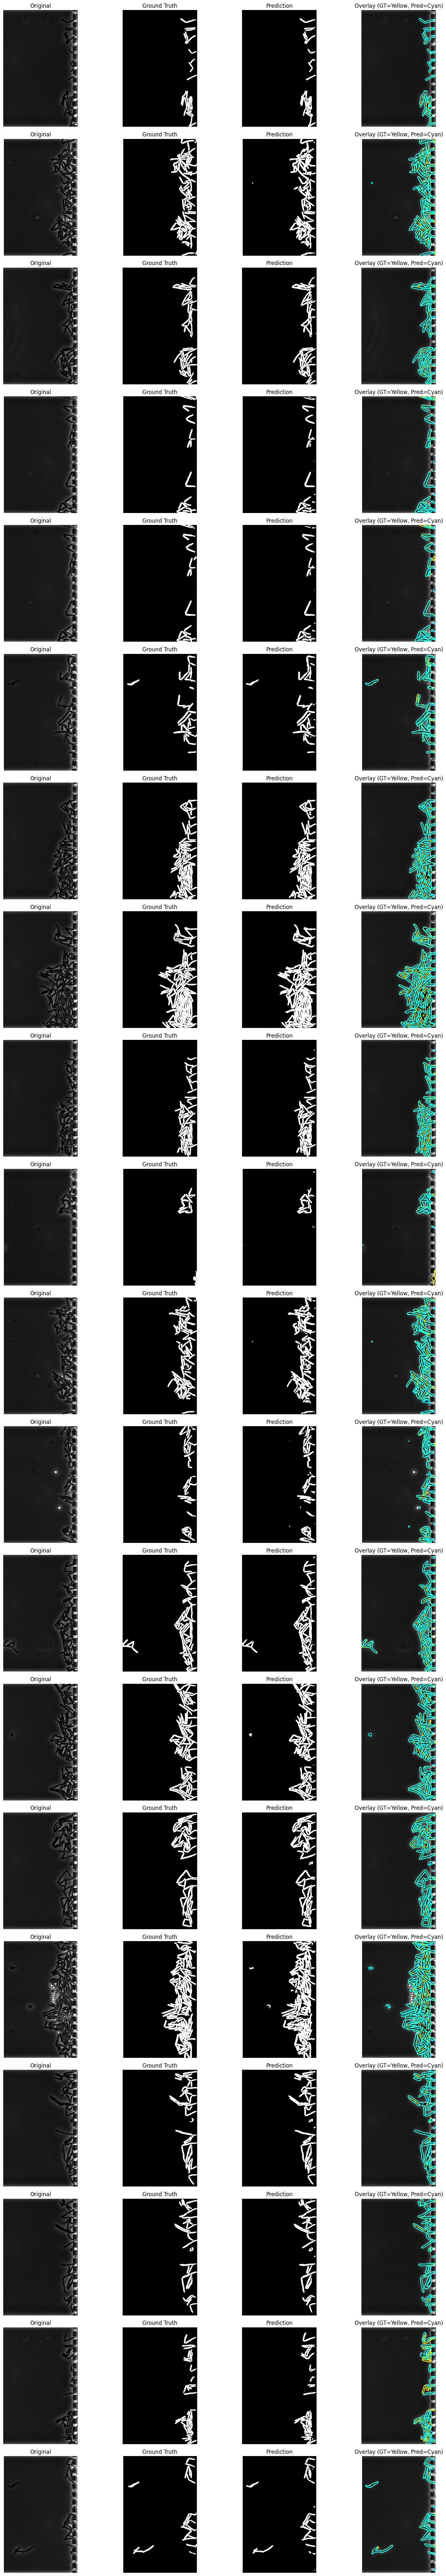

In [15]:
num_samples = 20
indices = np.random.choice(len(test_dataset), num_samples, replace=False)

plt.figure(figsize=(16, 4*num_samples))

for row, idx in enumerate(indices):
    sample = test_dataset[idx]

    image   = sample["image"]
    gt_mask = (sample["mask"] > 0).astype(np.uint8)

    pred = predict_mask(eval_fine_tuner, image)
    pred_bin = (pred > 0.5).astype(np.uint8)

    # ORIGINAL
    plt.subplot(num_samples, 4, row*4 + 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    # GROUND TRUTH
    plt.subplot(num_samples, 4, row*4 + 2)
    plt.imshow(gt_mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # PREDICTED MASK
    plt.subplot(num_samples, 4, row*4 + 3)
    plt.imshow(pred_bin, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    # OVERLAY
    plt.subplot(num_samples, 4, row*4 + 4)
    plt.imshow(image)
    plt.contour(gt_mask, colors="yellow", linewidths=1)
    plt.contour(pred_bin, colors="cyan", linewidths=1)
    plt.title("Overlay (GT=Yellow, Pred=Cyan)")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Saving the generated masks

In [19]:
import os
os.environ["IPYTHONDIR"] = "/tmp/ipython"  # or any writable folder

ref_out = "SAM_preds/REF"
rif_out = "SAM_preds/RIF10"

from pathlib import Path

def make_pos_folders(root, positions):
    root = Path(root)
    for p in positions:
        (root / f"Pos{p:03d}" / "PreprocessedPhaseMasks").mkdir(parents=True, exist_ok=True)

make_pos_folders(ref_out, range(111, 118))
make_pos_folders(rif_out, range(211, 218))

In [21]:
import re
from pathlib import Path
import numpy as np
from PIL import Image

def parse_pos_from_string(s: str) -> int:
    m = re.search(r"Pos(\d+)", s)
    if not m:
        raise ValueError(f"Could not find Pos### in: {s}")
    return int(m.group(1))

def get_image_path_from_sample(sample):
    # Try common keys. Adjust if your dataset uses something else.
    for k in ["image_path", "img_path", "path", "filepath", "file_path"]:
        if k in sample:
            return sample[k]
    if "meta" in sample and isinstance(sample["meta"], dict):
        for k in ["image_path", "img_path", "path", "filepath", "file_path"]:
            if k in sample["meta"]:
                return sample["meta"][k]
    return None

def save_sam_masks_png(fine_tuner, loader, ref_root, rif_root, threshold=0.5):
    ref_root = Path(ref_root)
    rif_root = Path(rif_root)

    saved = 0
    for batch in loader:
        for sample in batch:
            # --- position routing ---
            img_path = get_image_path_from_sample(sample)
            if img_path is not None:
                pos = parse_pos_from_string(str(img_path))
            else:
                # If there is no path, you MUST have position somewhere else.
                # Try sample['position'] if present; otherwise you need to expose it.
                if "position" in sample:
                    pos = int(sample["position"])
                elif "meta" in sample and "position" in sample["meta"]:
                    pos = int(sample["meta"]["position"])
                else:
                    raise ValueError("Cannot determine position. Sample has no image path or position field.")

            root = ref_root if pos < 200 else rif_root
            out_dir = root / f"Pos{pos:03d}" / "PreprocessedPhaseMasks"
            out_dir.mkdir(parents=True, exist_ok=True)

            # --- filename ---
            if img_path is not None:
                name = Path(str(img_path)).stem
            else:
                name = f"sample_{saved:06d}"

            out_path = out_dir / f"{name}.png"

            # --- predict using your function ---
            # sample['image'] must be HxWx3 numpy array (as in your evaluate_on_loader)
            mask_prob = predict_mask(fine_tuner, sample["image"])   # (H, W) numpy float
            mask_bin = (mask_prob >= threshold).astype(np.uint8) * 255

            Image.fromarray(mask_bin).save(out_path)
            saved += 1

    print(f"Saved {saved} masks.")

In [22]:
save_sam_masks_png(eval_fine_tuner, test_loader, ref_out, rif_out, threshold=0.5)

Saved 1694 masks.
